## TE08 -Shreya Chavan (ANN-4)
- A university wants to classify students as Admitted (1) or Rejected (0) based on:

  -Entrance Exam Score

  -High School GPA

Weights: [0.0925 0.09  ]
Bias: -0.1


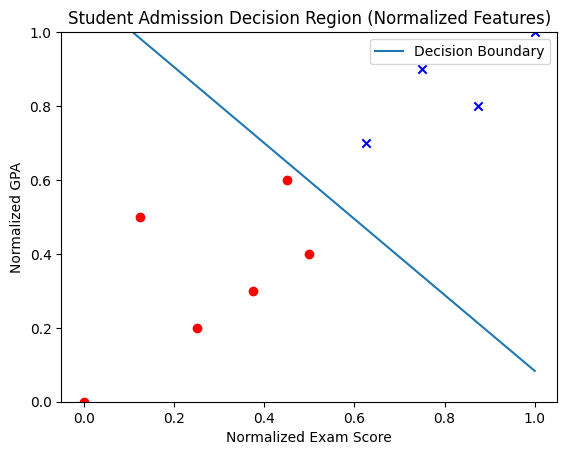

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original data: [Exam Score, GPA]
X_raw = np.array([
    [50, 3.0], [60, 3.2], [55, 3.5],
    [85, 3.8], [80, 3.9], [90, 4.0],
    [70, 3.4], [65, 3.3], [75, 3.7], [68, 3.6]
])
y = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 0])  # Added more labels accordingly

# Normalize features (Min-Max scaling)
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X = (X_raw - X_min) / (X_max - X_min)

# Initialize weights and bias
w = np.zeros(2)
b = 0
lr = 0.1  # Increased learning rate for faster convergence

def step(z):
    return 1 if z >= 0 else 0

# Training perceptron for 20 epochs
for epoch in range(20):
    for i in range(len(X)):
        pred = step(np.dot(w, X[i]) + b)
        w += lr * (y[i] - pred) * X[i]
        b += lr * (y[i] - pred)

print("Weights:", w)
print("Bias:", b)

# Plotting the normalized data
for i in range(len(X)):
    color = 'red' if y[i] == 0 else 'blue'
    marker = 'o' if y[i] == 0 else 'x'
    plt.scatter(X[i][0], X[i][1], color=color, marker=marker)

# Plot decision boundary in normalized scale
x_vals = np.linspace(0, 1, 100)
if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
else:
    y_vals = np.zeros_like(x_vals)  # If w[1] == 0, plot a horizontal line at 0

plt.plot(x_vals, y_vals, label='Decision Boundary')

plt.xlabel('Normalized Exam Score')
plt.ylabel('Normalized GPA')
plt.title('Student Admission Decision Region (Normalized Features)')
plt.legend()
plt.ylim([0, 1])
plt.show()